# [AI강의 II] 2회차 월말평가

## Solution.ipynb 파일

이 노트북은 AI 월말평가 정답을 작성하는 목적으로 작성 되었습니다.  
각 문제에 대한 설명은 두 곳에서 확인할 수 있습니다.
  1. 월말평가 문제 PDF 파일 (학사사이트): 각 문제의 목표와 배점
  2. 월말평가 Solution.ipynb: 각 문제에 대한 상세 설명

문제 설명에 대한 정답은 지금 보고 계신 Solution.ipynb 에 작성합니다.
  - 제출: Solution.ipynb 파일만 압축해서 제출합니다.
  - 자세한 제출 방법은 월말평가 문제 PDF 파일을 참고해 주세요

소스코드는 Reference.ipynb 를 참고하여 작성해주세요.

## 유의사항

👉 작성 전 반드시 아래 사항을 확인하세요.

- 문제 설명을 잘 읽고, `# 여기에 코드를 작성합니다` 와 같은 주석이 달린 영역에 코드를 작성하세요.

- 모든 코드는 실행했을 때 에러가 없어야 합니다.
- 코드 실행은 각 셀 단위로 가능합니다.

`ChatGPT 등 온라인 생성형 AI 서비스 및 Local LLM 사용은 강력히 금지합니다`

## 필수 Library 설치 안내

- SSAFY에서 공식적으로 배포한 Dockerfile Set을 기반으로 시험에 응시해야합니다. (ssafy_ai_2.zip)
- 아래 명시된 Library / Package 외 추가 설치를 금합니다.

In [8]:
!pip install -q "seaborn>=0.13.2"

---

## Problem 01: 데이터 생성 프롬프팅

- 주어진 user_prompt 변수에 프롬프트를 작성합니다.

- 총 두 개의 프롬프트를 작성해야 합니다.
  1. 데이터 증강을 통해 10개의 데이터를 생성할 수 있도록 프롬프트를 작성합니다.
  2. 데이터를 합성하여 10개의 데이터를 생성할 수 있도록 프롬프트를 작성합니다.

- 세부 사항은 다음과 같습니다.

### Problem 01-1) 데이터 증강

#### 문제 설명

```
데이터 증강을 목적으로 프롬프트를 아래와 같이 작성하였습니다.

그런데, 제대로 된 결과가 나오지 않았습니다.

few-shot 과 페르소나를 적절히 사용하여, 데이터 증강 목적에 맞는 새로운 문장 10개를 만들 수 있도록 프롬프트를 개선해야 합니다.

또한, 작성한 프롬프트를 모델에 넣었을 때 모델의 답변이 부가 설명 없이 10개의 데이터만 출력되어야 합니다.

원문: 오늘은 너무 즐거워
```

#### 정답 예시

```
- 오늘은 매우 즐겁다
- 오늘 하루가 너무 행복하다
- 오늘은 웃음이 가득한 날이다
- 오늘은 즐거움 그 자체다
- 오늘은 기쁨의 날이다
- 오늘은 정말 재미있었다
- 오늘은 행복감이 가득하다
- 오늘은 너무 기쁘다
- 오늘은 즐거운 시간이었다
- 오늘은 매우 행복했다
```

#### 답안 작성

In [9]:
# 아래 프롬프트를 수정합니다.
user_prompt = """
너는 주어진 예시를 바탕으로 데이터들만 생성하는 데이터 생성기야.
오늘은 너무 즐거워 라는 문장을 이용하여 비슷한 데이터들을 만들고자 해.

다음은 문장의 예시야.

오늘은 매우 즐겁다
오늘 하루가 너무 행복하다.
오늘은 웃음이 가득한 날이다.

다음 예시를 이용해서 부가 설명 없이 10개의 문장만 만들어줘.

"""

### Problem 01-2) CoT 프롬프트 엔지니어링 고도화

#### 문제 설명

```
Problem 01-1에서는 "오늘은 너무 즐거워"라는 문장을 기반으로
의미를 유지한 채 표현을 다양하게 바꾸는 데이터 증강을 수행하였습니다.

이번에는 문장과 감정(label)을 함께 포함하는 데이터셋을 생성하고자 합니다.

예시는 다음과 같습니다.
{sentence: "오늘 밥은 정말 맛있었어", label: "positive"}
{sentence: "오늘은 몸이 안 좋아", label: "negative"}

Chain-of-Thought와 페르소나를 활용하여,
"오늘은 너무 즐거워"와 유사한 맥락의 다양한 문장을 생성하고,
각 문장에 대해 감정(label)을 함께 포함한 데이터 10개를 생성할 수 있도록
프롬프트를 개선해주시기 바랍니다.

프롬프트에는 모델이 문장의 의미와 감정을 먼저 판단한 후,
이를 기반으로 데이터를 생성하도록 단계적인 사고 과정을 유도하는
Chain-of-Thought 구조가 포함되어야 합니다.

또한, 최종 출력은 부가 설명 없이 JSON 형식의 데이터 10개만 제시되어야 합니다.
```

#### 정답 예시

```
{
  "sentence": "오늘의 파티는 정말 재미있었습니다.",
  "label": "positive"
}

{
  "sentence": "내 친구들이랑 함께한 시간은 정말 행복했습니다.",
  "label": "positive"
}

...

{
  "sentence": "새로운 음식점에서 먹은 음식이 정말 맛있었습니다.",
  "label": "positive"
}
```

#### 답안 작성

In [ ]:
# 아래 프롬프트를 수정합니다.
user_prompt = """
너는 주어진 예시를 바탕으로 데이터셋을 만들어내는 데이터셋 생성기야.
다음 예시를 보고  {sentence: "오늘은 너무 즐거워", label: "positive"} 처럼 10개의 문장을 만들어줘.

예시 1 :{
  "sentence": "오늘의 파티는 정말 재미있었습니다.",
  "label": "positive"
}
예시 2 : {
  "sentence": "내 친구들이랑 함께한 시간은 정말 행복했습니다.",
  "label": "positive"
}

해당 문장을 만들어줄 때 다음 과정을 수행해줘.

1. 주어진 예시가 문장의 의미와 감정이 올바르게 담긴 예시인지 판단하기.
2. 주어진 예시를 바탕으로 문장의 의미와 감정이 담긴 데이터셋 10개 생성하기.
3. 만들어낸 데이터셋 10개가 문장의 의미와 감정이 올바르게 담긴 예시인지 확인하기.
4. 만들어낸 데이터셋 10개가 문장의 의미와 감정이 올바르게 짝지어진 예시인지 확인하기.
5. 해당 과정을 통해 만들어진 데이터셋 10개만을 부가 설명없이 JSON 형식으로 출력하기.
"""

---

## Problem 02: EDA와 선형회귀

- titanic 데이터를 분석하고, 회귀분석을 통해 데이터 예측을 하고자 합니다.

- 타이타닉(titanic) 데이터는 다음과 같은 정보가 있습니다.
  - `survivied` : 생존 여부 (0 = 사망, 1 = 생존)
  - `pclass` : 객실등급 (1~3), 1일수록 등급이 높습니다.
  - `class` : pclass를 문자 형태로 표현한 객실 등급 (First, Second, Third)
  - `sex` : 성별 (male, female)
  - `age` : 나이
  - `sibsp` : 함께 탑승한 형제 or 자매 or 배우자 수
  - `parch` : 함께 탑승한 부모 or 자녀 수
  - `fare` : 승객이 지불한 요금
  - `embarked` : 승선한 항구 (C = Cherbourg, Q = Queenstown, S = Southampton)
  - `who` : 탑승객 구분 (man, woman, child)
  - `adult_male` : 성인 남성 여부 (True / False)
  - `deck` : 선실 갑판 구역 (결측 688개)
  - `embark_town` : 승선 도시명 (Cherbourg, Queenstown, Southampton, 결측 2개)
  - `alive` : 생존 상태의 문자형 표현 (yes / no)
  - `alone` : 혼자 탑승 여부 (True / False)

- 요구사항에 맞는 EDA 분석과 적절한 코드를 작성합니다.
- 자세한 요구사항과 배점은 문제 PDF 파일을 참고하세요.

### Problem 02-1) 데이터 불러오기

#### 문제 설명

- seaborn의 `titanic` 데이터를 불러옵니다.

- 상위 10개의 데이터를 출력합니다.
  - 모든 필드값(column)이 출력되어야 합니다.

#### 답안 작성

In [1]:
# 이곳에 코드를 작성하시오.
import seaborn as sns

df = sns.load_dataset("titanic")

print(df.columns)
df.head(10)

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='str')


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False


### Problem 02-2) 컬럼별 결측치 개수 확인

#### 문제 설명

- 적절한 메서드를 활용하여, 각 컬럼별 결측치 개수를 출력합니다.

  - 결측치를 확인할 수 있는 코드라면, 어떤 코드라도 괜찮습니다.

#### 답안 작성

In [2]:
# 이곳에 코드를 작성하시오.
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

### Problem 02-3) 상관계수 출력하기

#### 문제 설명

- 생존여부(survived) 변수와 상관관계가 높은 5개의 변수를 찾고자 합니다.

- survived 와 다른 변수와의 상관계수를 확인할 수 있는 코드를 작성하세요.

  - 차트, 표, Log출력 등 어떠한 방식으로든 상관계수를 확인할 수 있으면 됩니다.

- 마지막으로 survived와 상관계수가 높은 변수 5개를 찾아 상관관계가 큰 순서대로 result 변수에 저장하고 출력하세요.


#### 답안 작성

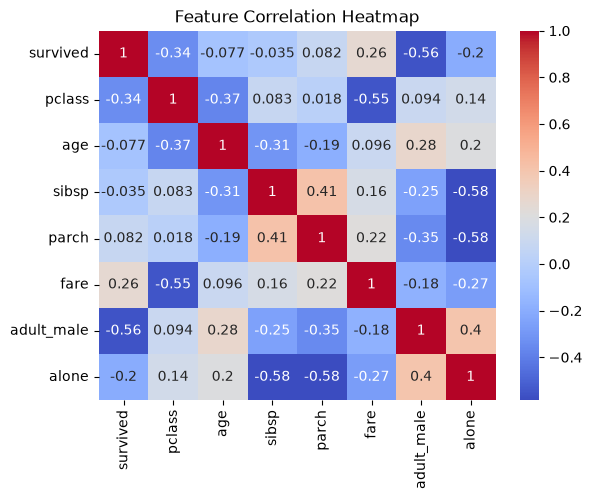

['fare', 'parch', 'sibsp', 'age', 'alone']


In [3]:
# 1. 상관계수를 확인할 수 있는 코드를 작성하시오.
import matplotlib.pyplot as plt

corr_with_survived = df.corr(numeric_only=True)["survived"].drop("survived")

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

# 2. 상관계수가 높은 변수 5개를 result 에 순서대로 저장 후 출력합니다.
result = corr_with_survived.sort_values(ascending=False).head(5).index.tolist()
print(result)

### Problem 02-4) 시각화

#### 문제 설명

- 나이(age)와 요금(fare) 두 변수의 관계를 시각적으로 확인할 수 있도록 적절한 차트를 활용하여 출력하세요.

- 추세선을 추가하여 두 변수의 관계를 더 명확히 표현하세요.
  - 추세선을 확인할 수 있다면, 어떠한 차트를 활용해도 무방합니다.

#### 답안 작성

R²: 0.03818997362968268


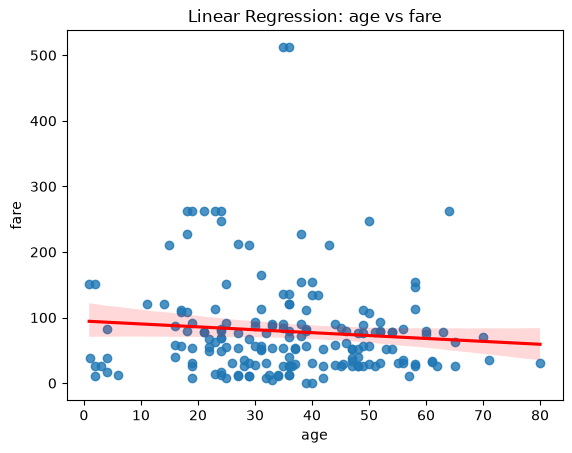

In [4]:
# 이곳에 코드를 작성하시오.
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

df = df.dropna()

X = df[["age"]]
y = df["fare"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("R²:", r2_score(y_test, y_pred))

sns.regplot(x="age", y="fare", data=df, line_kws={"color": "red"})
plt.title("Linear Regression: age vs fare")
plt.show()

### Problem 02-5) 통계지표와 상관계수를 통한 데이터 분석

#### 문제 설명

- 나이(age)와 요금(fare)의 데이터 관계를 분석하고자 합니다.

- 두 변수의 기초 통계지표(최소값, 최대값, 평균, 표준편차)를 출력하고, 각 변수의 분포적 특징을 간단히 서술하세요.

- 이어서 두 변수 간의 상관계수를 출력하여 관계의 방향(양/음)과 강도를 해석하세요.

- 마지막으로 result 변수에 통계지표 결과값과 상관계수 키워드를 포함하여 두 변수의 관계를 해석하세요.

#### 답안 작성

In [15]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,182.000000,182.000000,182.000000,182.000000,182.000000,182.000000
mean,0.675824,1.192308,35.623187,0.467033,0.478022,78.919735
std,0.469357,0.516411,15.671615,0.645007,0.755869,76.490774
min,0.000000,1.000000,0.920000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,24.000000,0.000000,0.000000,29.700000
50%,1.000000,1.000000,36.000000,0.000000,0.000000,57.000000
75%,1.000000,1.000000,47.750000,1.000000,1.000000,90.000000
max,1.000000,3.000000,80.000000,3.000000,4.000000,512.329200


In [27]:
# 1. 여기에 코드를 작성하시오.
# ...
corr_with_age_fare = df.corr(numeric_only=True)["age"]["fare"]
print(corr_with_age_fare)

result_corr = """ age와 fare는 음의 상관관계를 가지고 있으나 큰 수치를 가지고 있지는 않는다. 즉, age가 증가할수록 fare가 조금 작아지는 경향이 있다고 할 수 있다.
"""
print(result_corr)
# 2. 기초 통계지표를 통한 분석 결과와, 상관계수 키워드를 포함하여 두 변수의 관계를 자연스럽게 서술하세요.
result = """age의 최소, 최대는 0.92, 80 이며, fare의 최소 최대는 0, 512이다. 평균은 age, fare 각각 35.62, 78.91이고 표준편차는 각각 0.51, 76.49이다.
둘 다 범위가 넓으며 age와 fare의 상관계수는 -0.096이므로 작은 음의 상관관계를 가지고 있다."""
print(result)

-0.09073036394094938
 age와 fare는 음의 상관관계를 가지고 있으나 큰 수치를 가지고 있지는 않는다. 즉, age가 증가할수록 fare가 조금 작아지는 경향이 있다고 할 수 있다.

age의 최소, 최대는 0.92, 80 이며, fare의 최소 최대는 0, 512이다. 평균은 age, fare 각각 35.62, 78.91이고 표준편차는 각각 0.51, 76.49이다.
둘 다 범위가 넓으며 age와 fare의 상관계수는 -0.096이므로 작은 음의 상관관계를 가지고 있다.


---

## Problem 03 : RAG 기술의 구현

- RAG 의 전체 흐름을 이해하고, 고객센터 정보를 참고하는 RAG 시스템을 구현하고자 합니다.


### Problem 03-1) RAG 동작 원리 설명하기

#### 문제 설명

- 다음 키워드를 모두 사용하여 RAG 전체 동작 원리를 설명하세요.


- 키워드
```
프롬프트 / LLM / 청킹 / 데이터 생성 / Vector DB / 임베딩 / 유사도 검색
```

#### 답안 작성

In [ ]:
# result 변수에 주어진 키워드를 모두 사용하여 RAG 전체 흐름을 자세히 적으세요.
result = """
RAG란 먼저 
1. text를 추출하여 청킹을 나눕니다.
2. 그리고 임베딩 벡터를 사용하여 벡터값을 추출합니다.
3. 얻은 벡터값을 Vector DB에 저장합니다.
4. 질문 프롬프트를 받은 뒤
5. 임베딩 벡터를 통해 얻은 벡터값을 이용하여, Retriever 검색기를 통해 유사도 검색을 합니다.
6. 질문과 얻은 결과를 이용하여 프롬프트를 작성하고
7. 해당 프롬프트를 LLM에 보냅니다.
8. 데이터 생성을 통해 더 좋은 결과값을 얻게 됩니다.
"""

print(result)

### Problem 03-2) LangGraph RAG 흐름 완성하기

#### 문제 설명

- LangGraph를 활용하여 RAG(Retrieval-Augmented Generation) 시스템을 구현하였습니다.

- 검색(retrieve)과 응답 생성(generate)을 위한 각 노드는 정상적으로 정의되어 있습니다.

- 하지만, 노드 간의 흐름을 구성하는 그래프 연결 코드가 완성되지 않아 전체 시스템이 동작하지 않습니다.

- 제시된 코드 중 적절한 코드만을 선택하여, retrieve -> generate -> 종료(END) 흐름이 되도록 올바른 순서로 배치하시기 바랍니다.

  - 주어진 코드 외의 추가 작성은 하지 않습니다.

  - 모든 코드를 반드시 사용할 필요는 없으며, 필요한 코드만 선택하여 사용합니다.

- 주석 아래 부분에 코드를 추가하면 됩니다.

#### 답안 작성

#### 보기
  - 아래 코드 중 적절한 코드를 선택하여 올바른 순서로 배치합니다.

    ```
    graph.add_edge("generate", END)

    graph.add_node("generate", generate)

    graph = StateGraph(State)

    result = app.invoke({
        "question": "LangGraph가 뭐야?",
        "context": "",
        "answer": ""
    })

    graph.add_edge("retrieve", START)

    app = graph.compile()

    graph.set_entry_point("retrieve")

    graph.add_edge("retrieve", "generate")

    graph.add_edge(START, "retrieve")

    graph.add_node("retrieve", retrieve)

    graph.set_entry_point("generate")

    graph.add_edge("retrieve", END)

    graph.add_node("END", END)

    graph.add_edge("generate", "retrieve")
    ```

In [7]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

class State(TypedDict):
    question: str
    context: str
    answer: str

def retrieve(state: State):
    return {"context": "검색 결과"}

def generate(state: State):
    return {"answer": "최종 답변"}

# -------------------------------------------
# 적절한 코드만을 선택하여 올바른 순서로 배치하세요.
# -------------------------------------------

graph = StateGraph(State) 

graph.add_node("retrieve", retrieve)
graph.add_node("generate", generate)

graph.add_edge(START, "retrieve")
graph.add_edge("retrieve", "generate")
graph.add_edge("generate", END)

app = graph.compile()

result = app.invoke({
    "question": "LangGraph가 뭐야?",
    "context": "",
    "answer": ""
})
# 결과 출력
for key, value in result.items():
    print(f"{key}: {value}")


question: LangGraph가 뭐야?
context: 검색 결과
answer: 최종 답변


#### 코드 수행 결과 예시

```
question: LangGraph가 뭐야?
context: 검색 결과
answer: 최종 답변
```